# Structural-Reflection Nambu Solution of the Kitaev-Chain Spectral Problem

## I. Introduction

This is the middle rung of the project's four-model study of the 1D Kitaev
chain. A single-head sinusoidal network (SIREN) maps the chemical potential
$\mu$ to a Nambu-basis Bogoliubov--de Gennes (BdG) eigenvector, exactly as in
the folded-spectrum baseline -- but here the chain's $\mu \to -\mu$
reflection symmetry is **built into the forward pass**, so the predicted
spectrum is even in $\mu$ by construction rather than by training. Training
is label-free and the objective is just

$$
\mathcal{L} \;=\; \mathcal{L}_{\mathrm{fsm}} \;+\; \mathcal{L}_{\mathrm{var}},
$$

two terms, no annealing schedule, no relative weights.

The baseline notebook established two facts on the same domain and metrics:
`loss_ph` is numerically identical to `loss_var` (particle--hole conjugation
makes it redundant), and `loss_pin` is a soft substitute for an energy-sign
guarantee. This notebook acts on both -- it drops `loss_ph` and `loss_pin` --
and folds in the third correction the baseline had to *learn*, the evenness
of the spectrum in $\mu$. What it deliberately does **not** fix is the
per-$\mu$ eigenvector inside the topological phase: `fsm + var` is flat over
the two-dimensional near-zero Majorana manifold, so that vector stays
undetermined (though, with the fold, now consistent between $+\mu$ and
$-\mu$). Removing that last ambiguity needs the chiral basis, and is the
subject of the fourth notebook. The collocation domain, the two-stage
optimiser, and the evaluation probe are shared across all four models.

## II. Formalism

### A. BdG Hamiltonian in the Nambu basis

In the Nambu basis
$\Psi = (c_1,\dots,c_N,c_1^\dagger,\dots,c_N^\dagger)^{\mathsf T}$ the BdG
Hamiltonian is a real symmetric $2N \times 2N$ matrix, linear in $\mu$,

$$
H(\mu) \;=\; H_{\mathrm{base}} \;+\; \mu\, H_{\mu\text{-diag}}
\;=\;
\begin{pmatrix} A(\mu) & B \\[2pt] B^{\mathsf T} & -A(\mu) \end{pmatrix},
\tag{1}
$$

with $A(\mu) = -t\,T_N - \mu\,\mathbb{1}$ carrying the hopping ($T_N$ is the
nearest-neighbour adjacency) and the on-site potential, and $B$ the
antisymmetric $p$-wave pairing block. Particle--hole conjugation
$\Xi\,H(\mu)\,\Xi = -H(\mu)$ holds identically, with
$\Xi = \tau_x \otimes \mathbb{1}_N$ (real, symmetric, orthogonal).

### B. Spectral target and the near-zero degeneracy

The target is the lowest non-negative eigenvalue $E(\mu)$ of $H(\mu)$ and its
eigenvector $\psi(\mu) = (p, h)$ (particle, hole blocks). Throughout the
topological phase $|\mu| < 2t$ it is a near-zero mode with an edge-localised
eigenvector; in the trivial phase it rises as $E \to |\mu| - 2t$. Deep in the
topological phase the $\pm\lambda_1$ pair is split by only
$\lambda_1 \sim \mathrm{e}^{-N/\xi} \approx 2\times10^{-5}$, so the two exact
near-zero eigenvectors span a genuinely two-dimensional subspace; eigenvector
accuracy there is measured as the projection norm onto that span, not a
single-vector overlap (see `docs/markdown/derivations/topological-eigenvector-ambiguity.md`).

### C. The two redundancies the baseline exposed

- **`loss_ph` $\equiv$ `loss_var`.** With $\Xi H \Xi = -H$ and $\Xi$
  orthogonal,
  $\lVert H(\Xi\psi) + E_R\,\Xi\psi \rVert = \lVert H\psi - E_R\psi \rVert$
  term by term, so the particle--hole residual carries no independent
  gradient (`docs/markdown/derivations/particle-hole-redundancy.md`). **Dropped here.**
- **`loss_pin` as a soft branch-fixer.** $\mathcal{L}_{\mathrm{fsm}} +
  \mathcal{L}_{\mathrm{var}}$ is exactly invariant under $\psi \to \Xi\psi$,
  which sends $E_R \to -E_R$; it does not distinguish the $+E_R$ from the
  $-E_R$ branch. The baseline's annealed
  $\operatorname{softplus}(-E_R)$ pin softly rewards $E_R \ge 0$. **Dropped
  here**; the $\pm E$ branch is treated as a global gauge and fixed at
  *evaluation* time by sign-alignment to the reference, exactly as the
  chiral notebook does with `resolve_singular_branch`. Reported energy is
  $|E_R|$.

### D. The $\mu \to -\mu$ reflection, folded into the architecture

Let $D = \mathrm{diag}((-1)^n)$ act on an $N$-vector and, for a Nambu vector
$\psi = (p, h)$, define $\Gamma\psi = (-D h,\, -D p)$. Then
$\Gamma = -(\tau_x \otimes D)$ is real, symmetric, orthogonal and involutory
($\Gamma^2 = \mathbb{1}$), and block algebra ($D T_N D = -T_N$,
$D B D = B^{\mathsf T} = -B$) gives the exact identity

$$
\Gamma\,H(\mu)\,\Gamma \;=\; H(-\mu).
\tag{2}
$$

This is the Nambu-basis form of the chiral block's
$h(-\mu) = -D\,h(\mu)\,D$. With $g$ the raw backbone-plus-head map, the
network returns

$$
\psi(\mu) \;=\; \operatorname{normalise}
\!\left( \tfrac12\big[\, g(\mu) + \Gamma\, g(-\mu) \,\big] \right),
\tag{3}
$$

so that, using $\Gamma^2 = \mathbb{1}$ and that $\operatorname{normalise}$
commutes with the orthogonal $\Gamma$,

$$
\psi(-\mu) \equiv \Gamma\,\psi(\mu),
\qquad
E_R(-\mu) = \psi(-\mu)^{\mathsf T} H(-\mu)\,\psi(-\mu)
= \psi(\mu)^{\mathsf T} H(\mu)\,\psi(\mu) = E_R(\mu),
$$

both **exactly**. The spectrum is even in $\mu$ by construction; the baseline
had to learn this and its Fig. 6 still showed a nonzero residual.

### E. What remains soft

$\mathcal{L}_{\mathrm{fsm}} + \mathcal{L}_{\mathrm{var}}$ still only asks that
$\psi$ be *an* eigenvector near $E = 0$; it does not select a vector within
the two-dimensional topological manifold. With the fold, whatever internal
angle the network settles on it settles on **consistently** across the
domain -- "arbitrary but consistent", the correct state for a subspace
solver. Fig. 5 shows this: the topological columns are one arbitrary section
of the manifold, identical between $+\mu$ and $-\mu$ up to the
particle$\leftrightarrow$hole swap of $\Gamma$. Removing the arbitrariness
itself needs the chiral basis, where the smallest singular value is simple
(notebook 4).

## III. Network architecture

`SirenPINNNambuFolded` is a SIREN with a single linear head,
$\mu \longmapsto \psi(\mu) \in \mathbb{R}^{2N}$, evaluated at both $+\mu$ and
$-\mu$ and combined by Eq. (3). Its `n_sites` is the full BdG dimension
$2N = 40$ -- the **same** convention as the baseline's `SirenPINN`, and
deliberately unlike the chiral model (whose `n_sites` is $N$). `input_scale`
is $4.0$, matching $|\mu| \le 4t$.

| property | baseline `SirenPINN` | this model | chiral `SirenPINNChiral` |
|---|---|---|---|
| $\lVert \psi \rVert = 1$ | structural | structural | structural |
| $E(-\mu) = E(\mu)$ | learned | **structural** | structural |
| $E \ge 0$ | soft (`loss_pin`) | gauge, fixed at eval | structural |
| $\pm E$ spectral pairing | soft | soft | structural |
| $\Xi$-partner eigenvector | soft (`loss_ph`) | soft | structural |
| $\psi$ is an eigenvector | soft (`loss_var`) | soft (`loss_var`) | soft (`loss_var`) |

Unlike the chiral fold, whose $-D$ factor on a single vector is
sign-discontinuous at $\mu = 0$, Eq. (3) forces
$\psi(0) = \operatorname{normalise}(\tfrac12(\mathbb{1} + \Gamma)\,g(0))$ --
the projection onto the $+1$ eigenspace of $\Gamma$, continuous through
$\mu = 0$. Sampling $\mu$ down to $0$ is therefore valid here.
`hidden_omega_0` and `hidden_layers` are the reserved ablation axes.

## IV. Loss functional

`NambuFSMLoss` is `PinnedFSMLoss` with `loss_ph` and `loss_pin` removed -- the
Nambu-basis counterpart of the chiral notebook's `ChiralFSMLoss`, which is
already exactly this shape on the $N \times N$ block. `psi_pred = model(mu)`;
$E_R = \psi_{\mathrm{pred}}^{\mathsf T} H(\mu)\,\psi_{\mathrm{pred}}$ is the
Rayleigh quotient, reported as `lam_mean` $= \langle |E_R| \rangle$.

$$
\mathcal{L}_{\mathrm{fsm}} = \big\langle \lVert H(\mu)\,\psi \rVert^2 \big\rangle,
\qquad
\mathcal{L}_{\mathrm{var}} = \big\langle \lVert H(\mu)\,\psi - E_R\,\psi \rVert^2 \big\rangle,
\qquad
\mathcal{L} = \mathcal{L}_{\mathrm{fsm}} + \mathcal{L}_{\mathrm{var}}.
$$

| | baseline `PinnedFSMLoss` | this notebook `NambuFSMLoss` |
|---|---|---|
| physics terms | `fsm`, `var` | `fsm`, `var` |
| redundant term | `0.1 * ph` $(\equiv$ `var`$)$ | -- |
| soft branch pin | `w_pin(t) * pin`, annealed $1.0 \to 0.01$ | -- |
| schedule | yes | none |
| tunable weights | one fixed ($0.1$) + one schedule | none |

Because there is no epoch-keyed schedule, `run_two_phase`'s epoch-continuity
mechanism (`start_epoch = adam_epochs + 1`), which the baseline needed to
hold `w_pin` on its floor across the phase boundary, has nothing to act on
here -- a small simplification the two-term loss buys.

## V. Collocation sampling

The fold makes $\mu < 0$ an exact image of $\mu > 0$ (Eq. 3), so training
only needs $\mu \in [0, 4t]$. `NAMBU_HALF_DOMAIN_REGIONS` is a
`SamplingRegion` mixture over that half-domain: a uniform slice, a
**widened** window bracketing the transition at $\mu = 2t$ (out to
$\mu \approx 2.6t$, covering the trivial-side shoulder where $\lambda_1$
rises steeply from zero and the folded-spectrum residual is hardest), and
the trivial phase out to $4t$. The lower bound is $0.0$ -- valid here because
there is no $\mu = 0$ gauge kink (Sec. III), unlike the chiral notebook which
excludes $\mu \in [0, 0.05t)$.

The three-loader arrangement follows the other unsupervised notebooks:
`mode="infinite"` streaming for the AdamW stage (a fresh collocation batch
every step), a frozen large single-batch pool for the L-BFGS stage (a
quasi-Newton method needs a stationary objective), and a separate frozen pool
for the validation curve. Evaluation and every figure use a two-sided
$[-4t, 4t]$ grid; the negative half is a check on the fold.

## VI. Implementation

### A. Imports

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import torch
from accelerate import Accelerator
from sesh import Session

from kitaev.analytical import KitaevChainHamiltonian
from kitaev.data.sampling_region import SamplingRegion
from kitaev.models import RayleighEnergyAdapter, SirenPINNNambuFolded
from kitaev.training import BdGEvaluationProbe, TwoPhaseConfig, run_two_phase
from kitaev.training.config import TrainerConfig
from kitaev.training.loss import NambuFSMLoss
from kitaev.training.sampling import SamplingConfig, build_sampling
from kitaev.training.trainer import _build_kitaev_operators
from kitaev.visualisation import sweep_wavefunctions

### B. Session and device

In [2]:
session = Session(
    name="structural-nambu",
    output_root=Path("../../results/logs"),
    enable_mlflow=False,
)

accelerator = Accelerator()
session.info(f"Using device: {accelerator.device}")

2026-08-28 07:52:31 | INFO | structural-nambu | Experiment session: structural-nambu initialised.
2026-08-28 07:52:31 | INFO | structural-nambu | Seeding engine completed using base reference: 42
2026-08-28 07:52:31 | INFO | structural-nambu | Local workflow runtime tracking directed to: ../../results/logs/20260828_075230_structural-nambu
2026-08-28 07:52:31 | INFO | structural-nambu | Using device: mps


### C. Hamiltonian

`_build_kitaev_operators` assembles the batched
$(H_{\mathrm{base}},\, H_{\mu\text{-diag}},\, \Xi)$ triple. `NambuFSMLoss`
consumes $H_{\mathrm{base}}$ and $H_{\mu\text{-diag}}$ to form $H(\mu)$ for
its residual and **ignores** $\Xi$ (it has no particle--hole term). All
quantities are in units of $t$, with $N = 20$ and $\Delta = 0.5\,t$, so the
transition lies at $\mu = 2t$.

In [3]:
N = 20
t = 1.0
delta = 0.5
session.info(f"N = {N}, t = {t}, delta = {delta}, transition at |mu| = {2 * t}")

hamiltonian = KitaevChainHamiltonian(n_sites=N, hopping=t, pairing=delta)

H_base, H_mu_diag, Xi = _build_kitaev_operators(N, hopping=t, pairing=delta)
H_base = H_base.to(accelerator.device)
H_mu_diag = H_mu_diag.to(accelerator.device)
Xi = Xi.to(accelerator.device)

2026-08-28 07:52:31 | INFO | structural-nambu | N = 20, t = 1.0, delta = 0.5, transition at |mu| = 2.0


### D. Collocation sampling

The half-domain region mixture of Sec. V, passed to `build_sampling` for the
streaming AdamW loader (which also returns the per-epoch resampling
callback), plus two `mode="frozen"` pools -- one for the validation curve,
one large single-batch pool for the stationary L-BFGS objective.

In [4]:
torch.manual_seed(42)

NAMBU_HALF_DOMAIN_REGIONS = (
    SamplingRegion(low=0.0, high=4.0, weight=1.0),  # full half-domain slice
    SamplingRegion(low=1.7, high=2.6, weight=1.5),  # transition + trivial-side shoulder
    SamplingRegion(low=2.0, high=4.0, weight=0.5),  # trivial phase
)

sampling_config = SamplingConfig(
    mode="infinite",  # "frozen" | "infinite" | "curriculum" | "adaptive"
    batch_size=1024,
    steps_per_epoch=8,
    total_samples=8192,  # frozen-pool size ("frozen" only)
)

train_loader, sampling_callbacks = build_sampling(
    sampling_config, NAMBU_HALF_DOMAIN_REGIONS
)

# Stable held-out pool for the validation-loss curve.
val_loader, _ = build_sampling(
    SamplingConfig(mode="frozen", batch_size=1024, total_samples=1024),
    NAMBU_HALF_DOMAIN_REGIONS,
)

# One fixed collocation batch per epoch for the L-BFGS stage.
lbfgs_loader, _ = build_sampling(
    SamplingConfig(mode="frozen", batch_size=2048, total_samples=2048),
    NAMBU_HALF_DOMAIN_REGIONS,
)

session.info(
    f"sampling mode: {sampling_config.mode}; "
    f"{len(sampling_callbacks)} sampling callback(s)"
)

2026-08-28 07:52:31 | INFO | structural-nambu | sampling mode: infinite; 1 sampling callback(s)


### E. Network, loss, optimisation schedule, and error probe

`SirenPINNNambuFolded` outputs the full $2N = 40$-component Nambu
eigenvector; `input_scale = 4.0` matches the domain. `NambuFSMLoss` takes no
arguments -- no schedule, no weights.

`BdGEvaluationProbe` scores against exact diagonalisation on a fixed $\mu$
grid. The model returns only $\psi$, so it is bridged to the probe's
$(E, \psi)$ contract by `RayleighEnergyAdapter`, which attaches
$E_R = \psi^{\mathsf T} H(\mu)\,\psi$ (signed; the probe takes the absolute
value itself). The same probe and grid score the baseline and chiral models.

In [5]:
model = SirenPINNNambuFolded(
    n_sites=2 * N,
    hidden_features=64,
    hidden_layers=2,
    input_scale=4.0,
)

# Two terms: fsm + var.  No loss_ph (identically equal to loss_var), no
# loss_pin (the +-E branch is a gauge, fixed at evaluation), no schedule.
loss_fn = NambuFSMLoss()

# Stage 1: AdamW + cosine decay on the streaming loader.  Stage 2: L-BFGS +
# strong-Wolfe line search on the fixed pool.  No annealed weight to carry
# across the phase boundary.
TWO_PHASE = TwoPhaseConfig(
    adam_epochs=3000,
    adam_lr=8e-4,
    adam_weight_decay=1e-6,
    lbfgs_epochs=300,
    lbfgs_max_iter=25,
    lbfgs_history_size=20,
    lbfgs_line_search_fn="strong_wolfe",
)

two_phase_base = TrainerConfig(
    epochs=1, print_freq=300, patience=None, grad_clip_norm=1.0
)

probe = BdGEvaluationProbe(
    n_sites=N,
    hopping=t,
    pairing=delta,
    mu_grid=np.linspace(-4.0, 4.0, 240),
    every=50,
    session=session,
    adapt=lambda m: RayleighEnergyAdapter(m, n_sites=N, hopping=t, pairing=delta),
)

### F. Training

The functional $\mathcal{L}_{\mathrm{fsm}} + \mathcal{L}_{\mathrm{var}}$ is
minimised in two stages on a single network: $3000$ epochs of AdamW under a
cosine learning-rate decay on freshly drawn collocation batches, then $300$
epochs of L-BFGS under a strong-Wolfe line search on the fixed pool.
`run_two_phase` returns the trained model and both stages' histories
concatenated; this drives every figure of Sec. VII.

In [6]:
trained_model, history = run_two_phase(
    session=session,
    accelerator=accelerator,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
    H_base=H_base,
    H_mu_diag=H_mu_diag,
    Xi=Xi,
    two_phase=TWO_PHASE,
    base_config=two_phase_base,
    callbacks=[*sampling_callbacks, probe],  # sampler + error probe (AdamW)
    val_loader=val_loader,
    lbfgs_train_loader=lbfgs_loader,  # fixed pool for the L-BFGS stage
    lbfgs_callbacks=[probe],  # keep the probe, drop the streaming sampler
)

adam_epochs = TWO_PHASE.adam_epochs
session.info(
    f"two-phase run complete: {len(history['train_loss'])} epochs recorded "
    f"({adam_epochs} AdamW + {TWO_PHASE.lbfgs_epochs} L-BFGS)"
)
session.info(
    f"train loss   AdamW end: {history['train_loss'][adam_epochs - 1]:.4e}  "
    f"-> L-BFGS end: {history['train_loss'][-1]:.4e}"
)
session.info(
    f"E MAE        first probe: {history['probe_e_mae'][0]:.4e}  "
    f"-> last probe: {history['probe_e_mae'][-1]:.4e}"
)

2026-08-28 07:52:31 | INFO | structural-nambu | --- Two-phase: AdamW warm-up ---
2026-08-28 07:52:31 | INFO | structural-nambu | --- Starting training (NambuFSMLoss) ---
2026-08-28 07:52:31 | INFO | structural-nambu | probe | step     1 | E MAE 3.912e-01 (topo 1.561e-01, triv 6.262e-01) | edge MAE 4.260e-01 | infidelity 7.429e-01 (max 9.645e-01)
2026-08-28 07:52:33 | INFO | structural-nambu | probe | step    50 | E MAE 3.134e-02 (topo 1.488e-02, triv 4.780e-02) | edge MAE 3.224e-02 | infidelity 9.575e-02 (max 8.886e-01)
2026-08-28 07:52:35 | INFO | structural-nambu | probe | step   100 | E MAE 1.222e-02 (topo 1.584e-03, triv 2.286e-02) | edge MAE 8.950e-03 | infidelity 2.053e-02 (max 7.699e-01)
2026-08-28 07:52:36 | INFO | structural-nambu | probe | step   150 | E MAE 7.910e-03 (topo 9.086e-04, triv 1.491e-02) | edge MAE 4.949e-03 | infidelity 1.012e-02 (max 7.594e-01)
2026-08-28 07:52:38 | INFO | structural-nambu | probe | step   200 | E MAE 6.607e-03 (topo 7.102e-04, triv 1.250e-02) 

## VII. Results

The trained network is wrapped in `RayleighEnergyAdapter`, exposing it as an
$(E, \psi)$ model: $E_R(\mu) = \psi^{\mathsf T} H(\mu)\,\psi$ (signed) and the
$2N$-component eigenvector. All comparisons are against exact diagonalisation
of $H(\mu)$ on a uniform grid over $[-4t, 4t]$.

### Figure style

The topological region $|\mu| < 2t$ is shaded and both transitions at
$\mu = \pm 2t$ are marked.

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

INK = "#1b2a41"
CORAL = "#e4572e"
TEAL = "#2a9d8f"
SLATE = "#8d99ae"
GOLD = "#e9c46a"

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": SLATE,
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.color": "#e6e8ec",
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 13,
        "axes.titleweight": "600",
        "axes.titlepad": 12,
        "axes.labelsize": 11,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": SLATE,
        "ytick.color": SLATE,
        "font.family": "sans-serif",
        "legend.frameon": False,
        "legend.fontsize": 10,
    }
)


def _mark_topological(ax, t, mu_max):
    """Shade the topological phase |mu| < 2t and mark both transitions."""
    ax.axvspan(-2 * t, 2 * t, color=TEAL, alpha=0.07, lw=0)
    for x in (-2 * t, 2 * t):
        ax.axvline(x, color=SLATE, ls=(0, (4, 3)), lw=1.1)
    ax.set_xlim(-mu_max, mu_max)
    ax.xaxis.set_major_locator(MultipleLocator(1.0))


def _annotate_phases(ax, t, y):
    ax.text(
        0.0,
        y,
        "topological",
        ha="center",
        va="center",
        fontsize=9,
        color=TEAL,
        weight="600",
    )
    for x in (-3 * t, 3 * t):
        ax.text(
            x,
            y,
            "trivial",
            ha="center",
            va="center",
            fontsize=9,
            color=SLATE,
            weight="600",
        )

### A. Optimisation history and physical error

Figure 1 shows the total loss and, on a second panel, its two components
$\mathcal{L}_{\mathrm{fsm}}$ and $\mathcal{L}_{\mathrm{var}}$ -- two curves,
not the baseline's five, and no twin axis for an annealed weight.
$\mathcal{L}_{\mathrm{fsm}}$ approaches its
$\big\langle \lambda_1(\mu)^2 \big\rangle$ trivial-phase floor;
$\mathcal{L}_{\mathrm{var}}$ keeps falling, further under L-BFGS.

Figure 2 plots the `BdGEvaluationProbe` metrics against the cumulative epoch
index -- energy MAE (topological / trivial), edge-weight MAE, and eigenvector
subspace infidelity. They fall by orders of magnitude across epochs where the
total loss is visually flat, the direct evidence that
$\mathcal{L}_{\mathrm{fsm}}$ on its floor is convergence, not a stall.

findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 600, now using 700.


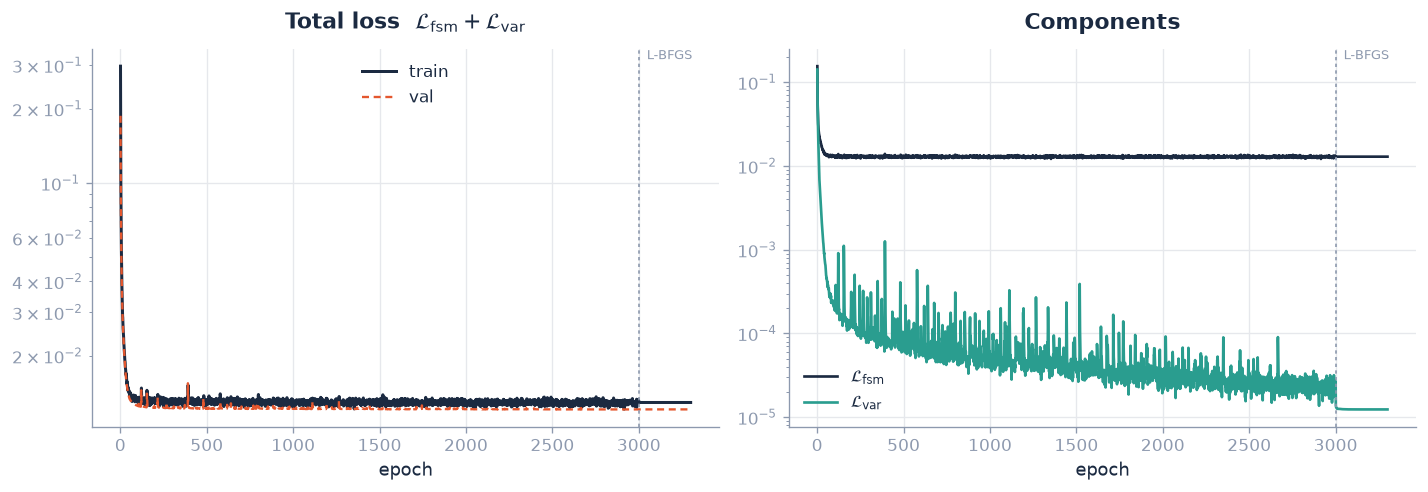

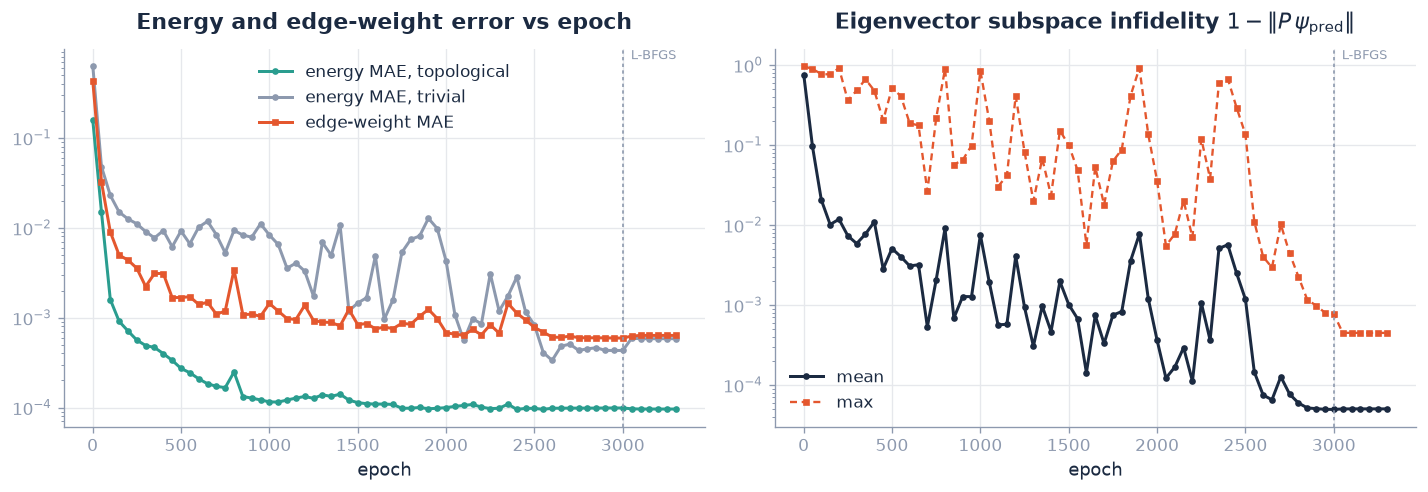

In [8]:
epochs = range(1, len(history["train_loss"]) + 1)
split = TWO_PHASE.adam_epochs  # AdamW -> L-BFGS hand-over


def _mark_phase_split(ax, top=True):
    ax.axvline(split, color=SLATE, ls=(0, (2, 2)), lw=1.0)
    ax.text(
        split,
        ax.get_ylim()[1] if top else ax.get_ylim()[0],
        "  L-BFGS",
        ha="left",
        va="top" if top else "bottom",
        fontsize=8,
        color=SLATE,
    )


# --- Figure 1: loss history and the two components ------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(epochs, history["train_loss"], color=INK, lw=1.8, label="train")
if "val_loss" in history:
    axes[0].plot(
        epochs, history["val_loss"], color=CORAL, lw=1.4, ls=(0, (3, 2)), label="val"
    )
axes[0].set_yscale("log")
axes[0].set_title(r"Total loss  $\mathcal{L}_{\rm fsm} + \mathcal{L}_{\rm var}$")
axes[0].set_xlabel("epoch")
_mark_phase_split(axes[0])
axes[0].legend()

axes[1].plot(
    epochs, history["train_fsm"], color=INK, lw=1.6, label=r"$\mathcal{L}_{\rm fsm}$"
)
axes[1].plot(
    epochs, history["train_var"], color=TEAL, lw=1.6, label=r"$\mathcal{L}_{\rm var}$"
)
axes[1].set_yscale("log")
axes[1].set_title("Components")
axes[1].set_xlabel("epoch")
_mark_phase_split(axes[1])
axes[1].legend(loc="lower left")

fig.tight_layout()
fig.savefig(session.path() / "loss_history.png", bbox_inches="tight")

# --- Figure 2: physical errors recorded by the probe --------------------
p_epoch = np.asarray(history["probe_epoch"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(
    p_epoch,
    history["probe_e_mae_topological"],
    color=TEAL,
    lw=1.8,
    marker="o",
    ms=3,
    label="energy MAE, topological",
)
axes[0].plot(
    p_epoch,
    history["probe_e_mae_trivial"],
    color=SLATE,
    lw=1.8,
    marker="o",
    ms=3,
    label="energy MAE, trivial",
)
axes[0].plot(
    p_epoch,
    history["probe_edge_mae"],
    color=CORAL,
    lw=1.8,
    marker="s",
    ms=3,
    label="edge-weight MAE",
)
axes[0].set_yscale("log")
axes[0].set_title("Energy and edge-weight error vs epoch")
axes[0].set_xlabel("epoch")
_mark_phase_split(axes[0])
axes[0].legend()

axes[1].plot(
    p_epoch,
    history["probe_subspace_infidelity"],
    color=INK,
    lw=1.8,
    marker="o",
    ms=3,
    label="mean",
)
axes[1].plot(
    p_epoch,
    history["probe_subspace_infidelity_max"],
    color=CORAL,
    lw=1.4,
    ls=(0, (3, 2)),
    marker="s",
    ms=3,
    label="max",
)
axes[1].set_yscale("log")
axes[1].set_title(r"Eigenvector subspace infidelity $1 - \|P\,\psi_{\rm pred}\|$")
axes[1].set_xlabel("epoch")
_mark_phase_split(axes[1])
axes[1].legend()

fig.tight_layout()
fig.savefig(session.path() / "probe_history.png", bbox_inches="tight")

### B. Lowest eigenvalue

Figure 3 compares $|E_R(\mu)|$ with exact diagonalisation across
$\mu \in [-4t, 4t]$ -- the near-zero mode throughout $|\mu| < 2t$ and the
linear approach $E \to |\mu| - 2t$ beyond. The inset shows the absolute error
on a logarithmic scale; the per-phase MAE is in the log output. By Eq. (3)
the curve is exactly symmetric about $\mu = 0$.

findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 600, now using 700.
2026-08-28 07:54:18 | INFO | structural-nambu | |E_R(mu)| MAE over [-4t, 4t]:    2.3700e-03
2026-08-28 07:54:18 | INFO | structural-nambu | E MAE, topological (|mu| < 2t): 9.8201e-05
2026-08-28 07:54:18 | INFO | structural-nambu | E MAE, trivial     (|mu| > 2t): 4.6419e-03


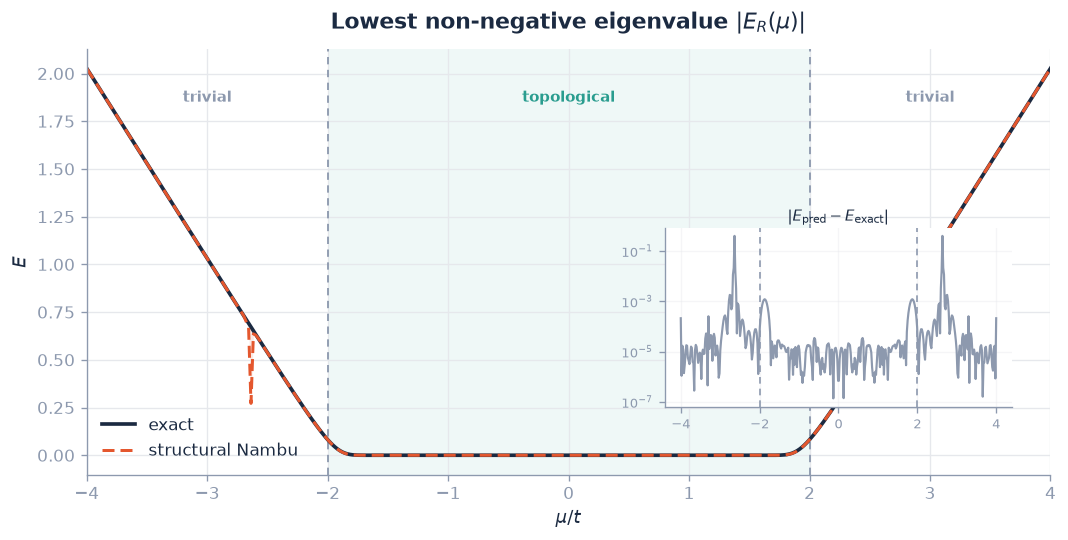

In [9]:
adapter = RayleighEnergyAdapter(trained_model, n_sites=N, hopping=t, pairing=delta).to(
    accelerator.device
)
adapter.eval()

mu_sweep = np.linspace(-4.0, 4.0, 400)
with torch.no_grad():
    mu_tensor = torch.tensor(
        mu_sweep[:, None], dtype=torch.float32, device=accelerator.device
    )
    e_pred_t, psi_pred_t = adapter(mu_tensor)
e_pred = np.abs(e_pred_t.cpu().numpy().ravel())  # |E_R|: the branch is a gauge
psi_pred = psi_pred_t.cpu().numpy()

e_exact = np.array(
    [np.linalg.eigvalsh(hamiltonian.build(float(m)))[N] for m in mu_sweep]
)
abs_err = np.abs(e_pred - e_exact)
topo = np.abs(mu_sweep) < 2 * t

fig, ax = plt.subplots(figsize=(9, 4.6))
_mark_topological(ax, t, 4.0)
ax.plot(mu_sweep, e_exact, color=INK, lw=2.2, label="exact")
ax.plot(mu_sweep, e_pred, color=CORAL, lw=1.8, ls=(0, (4, 2)), label="structural Nambu")
ax.fill_between(mu_sweep, e_exact, e_pred, color=CORAL, alpha=0.12, lw=0)
ax.set_title(r"Lowest non-negative eigenvalue $|E_R(\mu)|$")
ax.set_xlabel(r"$\mu / t$")
ax.set_ylabel(r"$E$")
_annotate_phases(ax, t, y=ax.get_ylim()[1] * 0.88)
ax.legend(loc="lower left")

inset = ax.inset_axes([0.60, 0.16, 0.36, 0.42])
inset.plot(mu_sweep, abs_err, color=SLATE, lw=1.3)
for x in (-2 * t, 2 * t):
    inset.axvline(x, color=SLATE, ls=(0, (4, 3)), lw=1.0)
inset.set_yscale("log")
inset.set_title(r"$|E_{\rm pred} - E_{\rm exact}|$", fontsize=9, pad=4)
inset.tick_params(labelsize=8)
inset.grid(True, alpha=0.4)

fig.tight_layout()
fig.savefig(session.path() / "energy_sweep.png", bbox_inches="tight")

session.info(f"|E_R(mu)| MAE over [-4t, 4t]:    {abs_err.mean():.4e}")
session.info(f"E MAE, topological (|mu| < 2t): {abs_err[topo].mean():.4e}")
session.info(f"E MAE, trivial     (|mu| > 2t): {abs_err[~topo].mean():.4e}")

### C. Eigenvector fidelity and edge localisation

The left panel of Fig. 4 reports $\lVert P\,\psi_{\mathrm{pred}} \rVert$, the
projection of the prediction onto the span of the two exact eigenvectors of
smallest $|E|$ -- the gauge-invariant accuracy measure where the
$\pm\lambda_1$ pair is degenerate. The right panel shows the combined
particle and hole weight on the two outermost sites at each end. Both are
$\mathrm{O}(2)$-invariant, so both are exactly symmetric in $\mu$.

2026-08-28 07:54:19 | INFO | structural-nambu | mean subspace fidelity: 0.9999  (min 0.9984)
2026-08-28 07:54:19 | INFO | structural-nambu | edge-weight MAE: 6.4483e-04


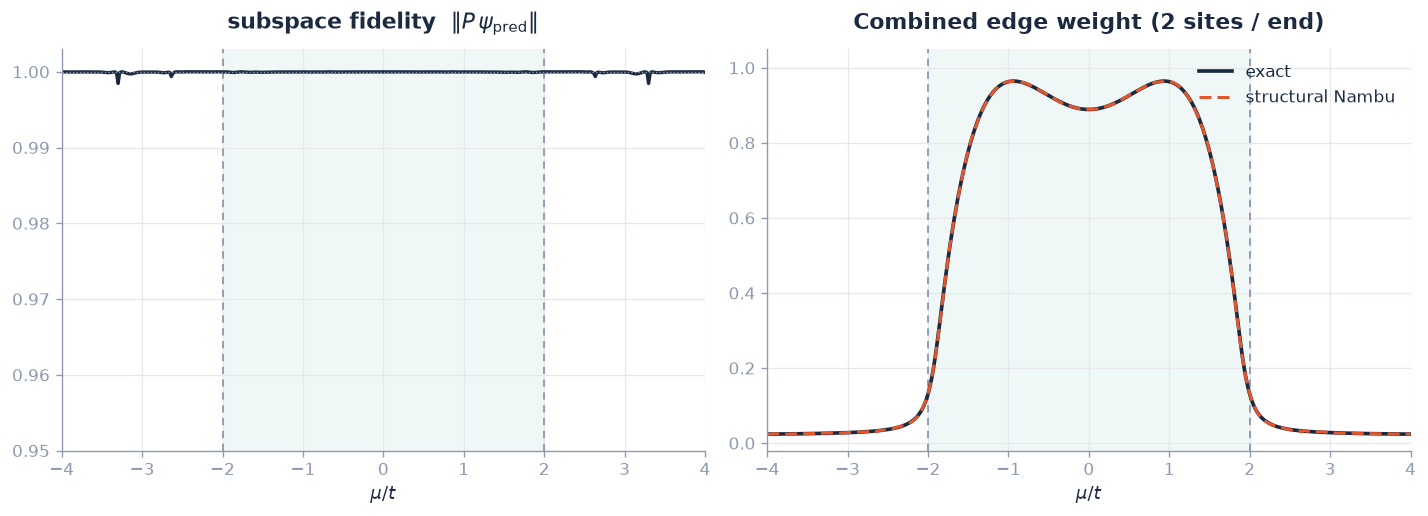

In [10]:
n_edge = 2
edge_idx = np.r_[0:n_edge, N - n_edge : N]

subspace_fidelity = np.empty_like(mu_sweep)
edge_exact = np.empty_like(mu_sweep)
for i, m in enumerate(mu_sweep):
    w, V = np.linalg.eigh(hamiltonian.build(float(m)))
    near_zero = V[:, np.argsort(np.abs(w))[:2]]  # the +/- lambda_min pair
    subspace_fidelity[i] = np.linalg.norm(near_zero.T @ psi_pred[i])
    psi_e = V[:, N]
    edge_exact[i] = (psi_e[:N][edge_idx] ** 2).sum() + (psi_e[N:][edge_idx] ** 2).sum()

prob_pred = psi_pred**2
edge_pred = prob_pred[:, :N][:, edge_idx].sum(1) + prob_pred[:, N:][:, edge_idx].sum(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

_mark_topological(axes[0], t, 4.0)
axes[0].plot(mu_sweep, subspace_fidelity, color=INK, lw=2.0)
axes[0].set_ylim(min(0.95, subspace_fidelity.min() - 0.01), 1.003)
axes[0].axhline(1.0, color=SLATE, lw=0.8, ls=":")
axes[0].set_title(r"subspace fidelity  $\|P\,\psi_{\rm pred}\|$")
axes[0].set_xlabel(r"$\mu / t$")

_mark_topological(axes[1], t, 4.0)
axes[1].plot(mu_sweep, edge_exact, color=INK, lw=2.2, label="exact")
axes[1].plot(
    mu_sweep, edge_pred, color=CORAL, lw=1.8, ls=(0, (4, 2)), label="structural Nambu"
)
axes[1].set_title("Combined edge weight (2 sites / end)")
axes[1].set_xlabel(r"$\mu / t$")
axes[1].set_ylim(-0.02, 1.05)
axes[1].legend(loc="upper right")

fig.tight_layout()
fig.savefig(session.path() / "eigenvector_agreement.png", bbox_inches="tight")

session.info(
    f"mean subspace fidelity: {subspace_fidelity.mean():.4f}  "
    f"(min {subspace_fidelity.min():.4f})"
)
session.info(f"edge-weight MAE: {np.abs(edge_pred - edge_exact).mean():.4e}")

### D. Probability densities

Figure 5 shows the particle- and hole-sector densities $|\psi_n|^2$ at
$\mu = \pm 3.4\,t$ (deep trivial), $\pm 1.0\,t$ (topological), and $0$.

Because `loss_pin` is gone the $\pm E_R$ branch is a free global gauge: in
the trivial phase the model may sit on $\Xi\psi$, with the particle and hole
sectors exchanged relative to `eigh`'s $V[:,N]$. For the trivial columns this
is resolved per $\mu$ before plotting -- whichever of $\{\psi,\,\Xi\psi\}$
better overlaps the reference is kept -- so those columns are a direct
per-site test.

The **topological** columns are shown as the raw prediction. There
$\mathcal{L}_{\mathrm{fsm}} + \mathcal{L}_{\mathrm{var}}$ is flat over the
two-dimensional near-zero manifold, so the prediction lands in the right
subspace (Fig. 4 left, $\lVert P\,\psi \rVert \approx 0.9999$) but on an
arbitrary rotation within it -- here piled onto the right end. The fold
(Eq. 3) makes that rotation **consistent between $+\mu$ and $-\mu$**: the
$\mu = -1$ and $\mu = +1$ columns are identical up to the
particle$\leftrightarrow$hole swap of $\Gamma$, invisible here because the
Majorana modes carry equal particle and hole weight -- something the baseline
could not manage (lopsided at $\mu = -1$, balanced at $\mu = +1$). The
$\mathrm{O}(2)$-invariant object is the **manifold density**
$\rho(n) = |\psi_+(n)|^2 + |\psi_-(n)|^2$, overlaid (dotted, as $\rho/2$) on
the topological columns; it integrates to $2$ over both sectors and is what a
single-vector FSM model can only reproduce after averaging over the internal
angle.

2026-08-28 07:54:19 | INFO | structural-nambu | Fig 5 branch vs eigh V[:, N]: mu=-3.4:Xi-flip, mu=-1.0:keep, mu=+0.0:keep, mu=+1.0:keep, mu=+3.4:Xi-flip


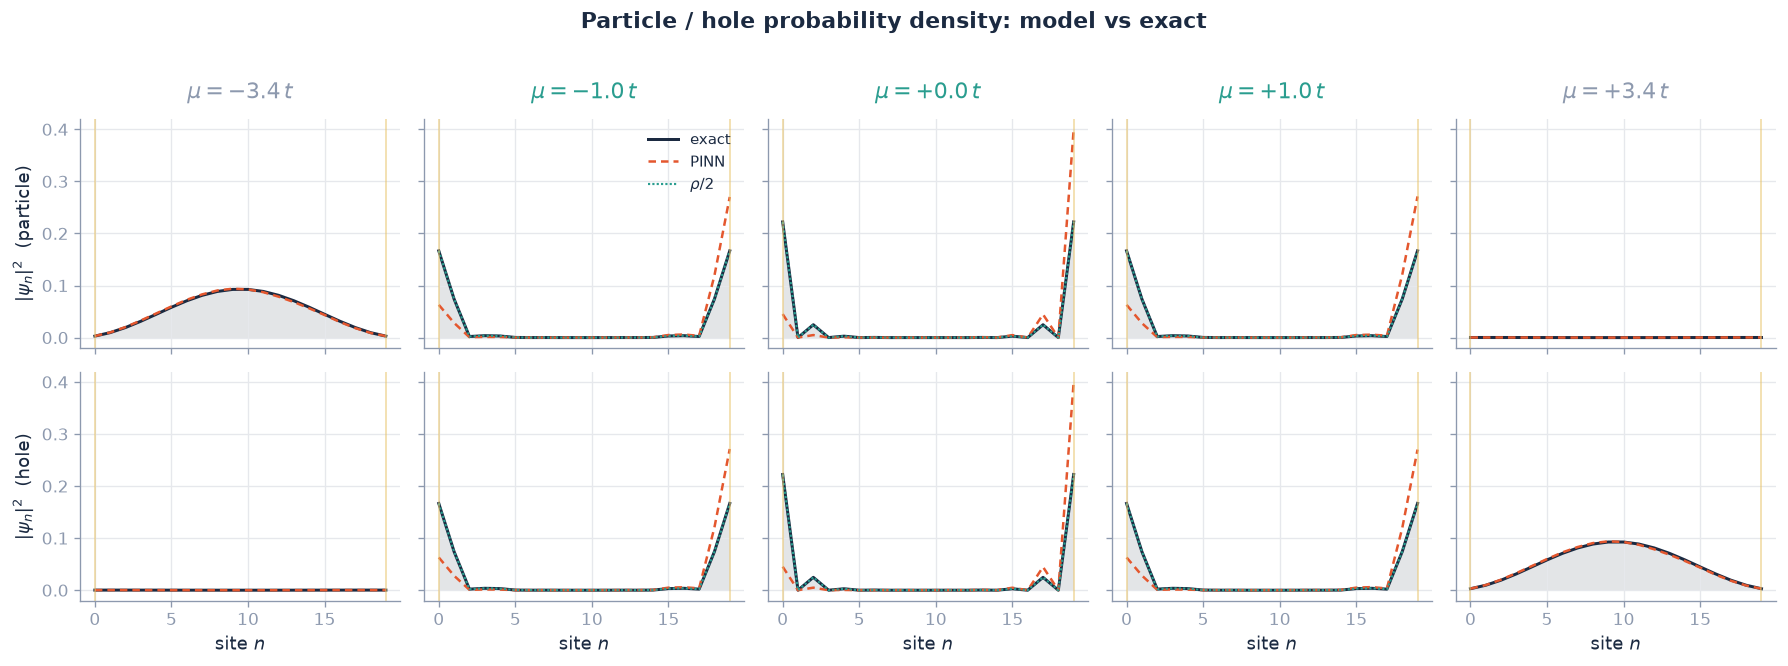

In [11]:
probe_mus = [-3.4, -1.0, 0.0, 1.0, 3.4]
wf = sweep_wavefunctions(adapter, hamiltonian, probe_mus, device=accelerator.device)
sites = wf.sites

# The +-E branch was left as a gauge (no loss_pin), so in the trivial phase
# the model may sit on Xi psi -- particle and hole sectors swapped relative
# to eigh's V[:, N]. Resolve it there per mu by keeping whichever of
# {psi, Xi psi} better overlaps the reference before splitting into sectors.
# The topological columns are left raw (a Xi flip is nearly a no-op on their
# density, and they are meant to show one arbitrary manifold section).
with torch.no_grad():
    mu_probe_t = torch.tensor(
        [[m] for m in probe_mus], dtype=torch.float32, device=accelerator.device
    )
    psi_probe = adapter(mu_probe_t)[1].cpu().numpy()

particle_pred = np.empty((len(probe_mus), N))
hole_pred = np.empty((len(probe_mus), N))
rho_particle, rho_hole = {}, {}
branch = {}
for col, mu in enumerate(probe_mus):
    w, V = np.linalg.eigh(hamiltonian.build(float(mu)))
    psi_ref = V[:, N]
    psi = psi_probe[col]
    psi_xi = np.concatenate([psi[N:], psi[:N]])  # Xi psi: swap particle/hole
    if abs(mu) >= 2 * t and abs(psi_xi @ psi_ref) > abs(psi @ psi_ref):
        psi, branch[mu] = psi_xi, "Xi-flip"
    else:
        branch[mu] = "keep"
    particle_pred[col] = psi[:N] ** 2
    hole_pred[col] = psi[N:] ** 2
    if abs(mu) < 2 * t:  # O(2)-invariant manifold density, topological only
        near = V[:, np.argsort(np.abs(w))[:2]]
        rho_particle[mu] = (near[:N, :] ** 2).sum(axis=1)
        rho_hole[mu] = (near[N:, :] ** 2).sum(axis=1)

fig, axes = plt.subplots(
    2, len(probe_mus), figsize=(3.0 * len(probe_mus), 5.4), sharex=True, sharey="row"
)

for col, mu in enumerate(probe_mus):
    is_topo = abs(mu) < 2 * t
    tag_color = TEAL if is_topo else SLATE
    for row, (exact, pred, label, rho) in enumerate(
        (
            (wf.particle_exact[col], particle_pred[col], "particle", rho_particle),
            (wf.hole_exact[col], hole_pred[col], "hole", rho_hole),
        )
    ):
        ax = axes[row, col]
        ax.fill_between(sites, exact, color=INK, alpha=0.12, lw=0)
        ax.plot(sites, exact, color=INK, lw=1.8, label="exact")
        ax.plot(sites, pred, color=CORAL, lw=1.5, ls=(0, (3, 2)), label="PINN")
        if is_topo:
            ax.plot(
                sites,
                rho[mu] / 2.0,
                color=TEAL,
                lw=1.3,
                ls=(0, (1, 1)),
                label=r"$\rho/2$",
            )
        for edge in (0, N - 1):
            ax.axvline(edge, color=GOLD, lw=1.0, alpha=0.6)
        if row == 0:
            ax.set_title(rf"$\mu = {mu:+.1f}\,t$", color=tag_color)
        if col == 0:
            ax.set_ylabel(rf"$|\psi_n|^2$  ({label})")
        if row == 1:
            ax.set_xlabel("site $n$")

axes[0, 1].legend(loc="upper right", fontsize=9)
fig.suptitle(
    "Particle / hole probability density: model vs exact",
    y=1.02,
    fontsize=13,
    weight="600",
)
fig.tight_layout()
fig.savefig(session.path() / "wavefunctions.png", bbox_inches="tight")

session.info(
    "Fig 5 branch vs eigh V[:, N]: "
    + ", ".join(f"mu={m:+.1f}:{b}" for m, b in branch.items())
)

### E. Structural reflection symmetry

`SirenPINNNambuFolded` builds $\psi(-\mu) \equiv \Gamma\,\psi(\mu)$ into the
forward pass (Eq. 3), so $E_R(-\mu) = E_R(\mu)$ holds to floating-point
tolerance, not as something the network had to learn. Figure 6 overlays
$|E_R(\mu)|$ and $|E_R(-\mu)|$ over $[0, 4t]$; the residual
$\max_\mu |E_R(-\mu) - E_R(\mu)|$ in the log output should sit at the
round-off level -- contrast the baseline, whose learned evenness left a
residual orders of magnitude larger.

2026-08-28 07:54:19 | INFO | structural-nambu | max |E_R(-mu) - E_R(mu)| (structural): 5.960e-07


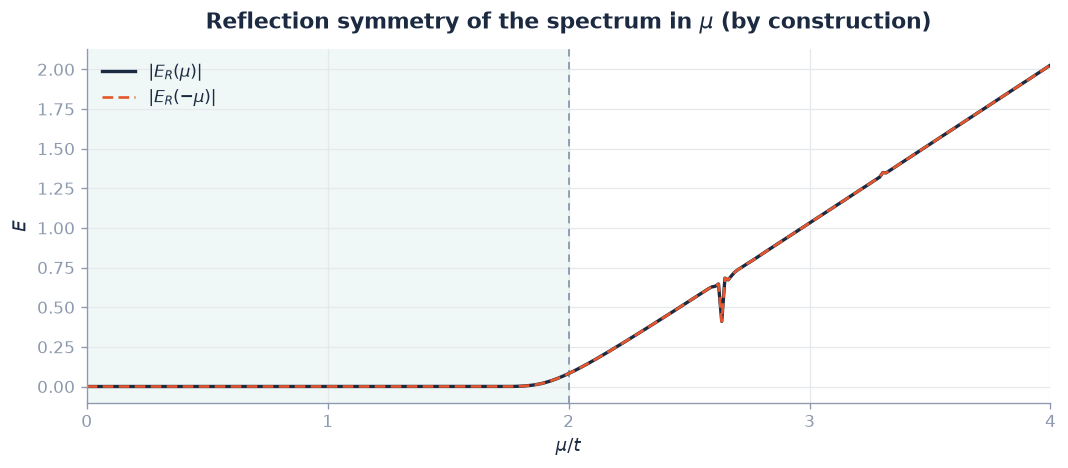

In [12]:
half = np.linspace(0.0, 4.0, 300)
with torch.no_grad():
    pos = torch.tensor(half[:, None], dtype=torch.float32, device=accelerator.device)
    e_pos = np.abs(adapter(pos)[0].cpu().numpy().ravel())
    e_neg = np.abs(adapter(-pos)[0].cpu().numpy().ravel())

fig, ax = plt.subplots(figsize=(9, 4.0))
_mark_topological(ax, t, 4.0)
ax.set_xlim(0, 4.0)
ax.plot(half, e_pos, color=INK, lw=2.0, label=r"$|E_R(\mu)|$")
ax.plot(half, e_neg, color=CORAL, lw=1.6, ls=(0, (4, 2)), label=r"$|E_R(-\mu)|$")
ax.set_title(r"Reflection symmetry of the spectrum in $\mu$ (by construction)")
ax.set_xlabel(r"$\mu / t$")
ax.set_ylabel(r"$E$")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(session.path() / "mu_reflection.png", bbox_inches="tight")

session.info(
    f"max |E_R(-mu) - E_R(mu)| (structural): {np.abs(e_neg - e_pos).max():.3e}"
)

## VIII. Summary

Folding the $\mu \to -\mu$ reflection into the network (Eq. 3) makes the
evenness of the spectrum exact and lets the loss drop to
$\mathcal{L}_{\mathrm{fsm}} + \mathcal{L}_{\mathrm{var}}$ -- two terms, no
schedule, no weights, the same shape as the chiral notebook's loss. The
redundant `loss_ph` and the soft `loss_pin` of the baseline are both gone;
the $\pm E$ branch is handled as a gauge and fixed at evaluation. Trained in
two stages over the folded domain $[0, 4t]$, the model reproduces the
spectrum, the edge localisation, and the subspace fidelity (Figs. 3--5), and
the reflection check (Fig. 6) is now satisfied to round-off.

What it does **not** resolve is the per-$\mu$ eigenvector inside the
topological phase: $\mathcal{L}_{\mathrm{fsm}} + \mathcal{L}_{\mathrm{var}}$
is flat over the two-dimensional near-zero manifold, so that vector is
arbitrary -- consistent between $+\mu$ and $-\mu$ thanks to the fold, but
still one undetermined rotation (Fig. 5, topological columns). The fourth
notebook removes it by moving to the chiral basis, where the smallest
singular value is simple. The numbers here -- per-phase energy MAE,
edge-weight MAE, subspace fidelity, reflection residual -- are the reference
that notebook is measured against.